In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup OK")

Setup OK


In [3]:
df = pd.read_csv('superstore.csv')

print(df.shape)

(9994, 15)


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Region,State,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,1,CA-2024-100000,2024-02-01,2024-02-05,Second Class,CG-10000,Corporate,West,California,Furniture,Furnishings,14.61,11,0.0,2.40
1,2,CA-2024-100001,2024-10-28,2024-11-03,Standard Class,CG-10001,Corporate,East,Pennsylvania,Office Supplies,Binders,18.74,12,0.0,4.39
2,3,CA-2021-100002,2021-01-22,2021-01-28,Standard Class,CG-10002,Consumer,West,Colorado,Furniture,Bookcases,201.09,14,0.5,-131.42
3,4,CA-2022-100003,2022-11-18,2022-11-18,Same Day,CG-10003,Corporate,South,Florida,Office Supplies,Appliances,156.40,9,0.2,-8.31
4,5,CA-2024-100004,2024-07-21,2024-07-23,First Class,CG-10004,Home Office,West,Washington,Technology,Copiers,129.71,12,0.2,-16.70


In [5]:
df.dtypes

Row ID            int64
Order ID            str
Order Date          str
Ship Date           str
Ship Mode           str
Customer ID         str
Segment             str
Region              str
State               str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.dtypes

Row ID                   int64
Order ID                   str
Order Date      datetime64[us]
Ship Date       datetime64[us]
Ship Mode                  str
Customer ID                str
Segment                    str
Region                     str
State                      str
Category                   str
Sub-Category               str
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object

In [7]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Region          0
State           0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2022-12-31 22:40:10.566339,2023-01-05 08:08:35.829497,265.843240,7.554333,0.120272,-8.004335
min,1.000000,2021-01-01 00:00:00,2021-01-03 00:00:00,5.000000,1.000000,0.000000,-850.590000
25%,2499.250000,2022-01-03 00:00:00,2022-01-08 00:00:00,36.625000,4.000000,0.000000,-11.140000
50%,4997.500000,2023-01-06 00:00:00,2023-01-10 00:00:00,133.945000,8.000000,0.100000,1.310000
75%,7495.750000,2023-12-25 00:00:00,2023-12-29 00:00:00,440.305000,11.000000,0.200000,25.417500
max,9994.000000,2024-12-30 00:00:00,2025-01-05 00:00:00,1915.530000,14.000000,0.500000,396.020000
std,2885.163629,NaN,NaN,298.027937,4.015319,0.147365,91.255315


In [9]:
print(f"Período: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Categorías: {df['Category'].unique()}")
print(f"Regiones: {df['Region'].unique()}")
print(f"Segmentos: {df['Segment'].unique()}")

Período: 2021-01-01 → 2024-12-30
Categorías: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Regiones: <StringArray>
['West', 'East', 'South', 'Central']
Length: 4, dtype: str
Segmentos: <StringArray>
['Corporate', 'Consumer', 'Home Office']
Length: 3, dtype: str


In [10]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month

df[['Order Date', 'year', 'month']].head()

,Order Date,year,month
0,2024-02-01,2024,2
1,2024-10-28,2024,10
2,2021-01-22,2021,1
3,2022-11-18,2022,11
4,2024-07-21,2024,7


In [11]:
df['quarter'] = df['Order Date'].dt.quarter
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Ship Date', 'quarter', 'days_to_ship']].head()

,Order Date,Ship Date,quarter,days_to_ship
0,2024-02-01,2024-02-05,1,4
1,2024-10-28,2024-11-03,4,6
2,2021-01-22,2021-01-28,1,6
3,2022-11-18,2022-11-18,4,0
4,2024-07-21,2024-07-23,3,2


In [12]:
df['profit_margin'] = df['Profit'] / df['Sales']

df[['Sales', 'Profit', 'profit_margin']].head()

,Sales,Profit,profit_margin
0,14.61,2.40,0.164271
1,18.74,4.39,0.234258
2,201.09,-131.42,-0.653538
3,156.40,-8.31,-0.053133
4,129.71,-16.70,-0.128749


In [13]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [14]:
ventas_categoria = df.groupby('Category')['Sales'].sum()

print(ventas_categoria)

Category
Furniture          1270833.65
Office Supplies     302785.41
Technology         1083218.28
Name: Sales, dtype: float64


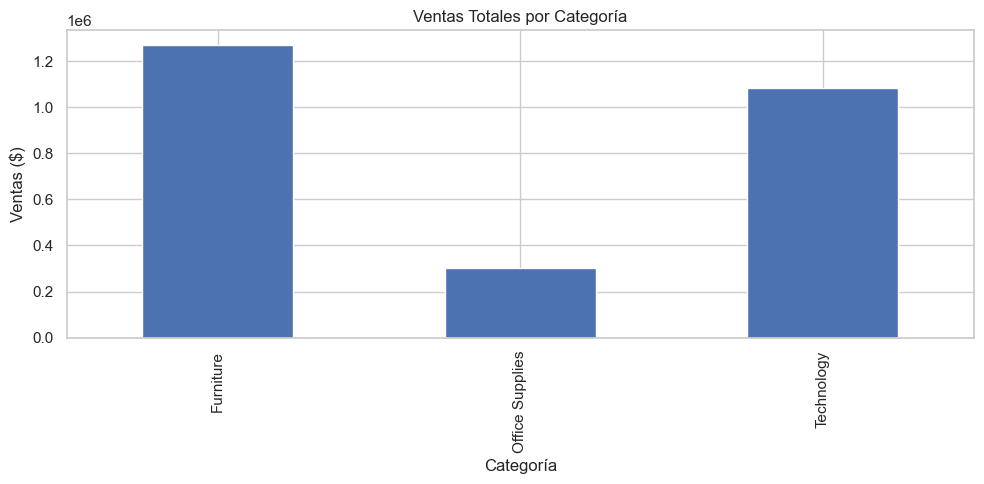

In [15]:
ventas_categoria.plot(kind='bar')

plt.title('Ventas Totales por Categoría')
plt.ylabel('Ventas ($)')
plt.xlabel('Categoría')
plt.tight_layout()
plt.show()

In [16]:
profit_categoria = df.groupby('Category')['Profit'].sum()

print(profit_categoria)

Category
Furniture         -100765.08
Office Supplies     20700.19
Technology             69.57
Name: Profit, dtype: float64


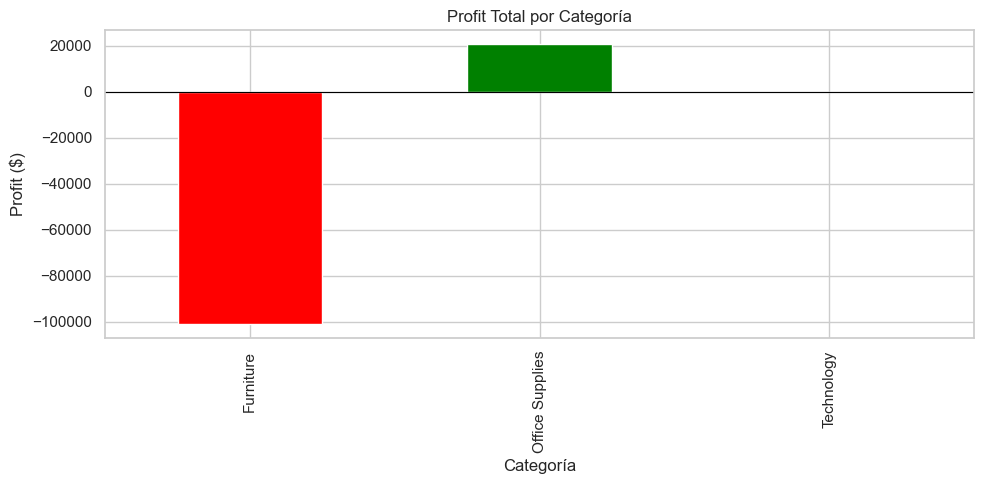

In [17]:
profit_categoria.plot(kind='bar', color=['red', 'green', 'green'])

plt.title('Profit Total por Categoría')
plt.ylabel('Profit ($)')
plt.xlabel('Categoría')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [18]:
descuento_profit = df.groupby('Discount')['Profit'].mean()

print(descuento_profit)

Discount
0.0     39.380855
0.1      0.498320
0.2    -39.278024
0.3    -78.373955
0.4   -121.966241
0.5   -153.851054
Name: Profit, dtype: float64


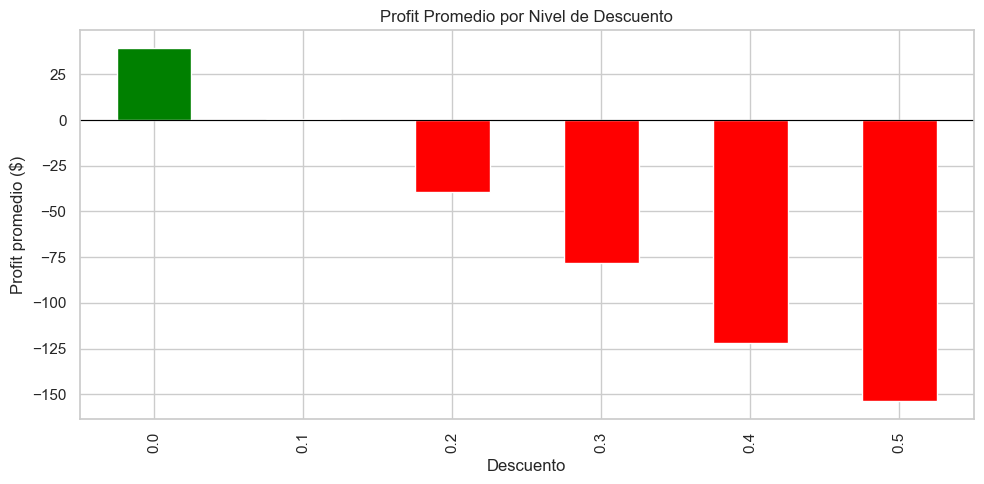

In [19]:
descuento_profit.plot(kind='bar', color=['green' if x >= 0 else 'red' for x in descuento_profit])

plt.title('Profit Promedio por Nivel de Descuento')
plt.ylabel('Profit promedio ($)')
plt.xlabel('Descuento')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [20]:
ventas_mes = df.groupby(['year', 'month'])['Sales'].sum().reset_index()

print(ventas_mes.head(10))

   year  month     Sales
0  2021      1  56966.33
1  2021      2  43530.59
2  2021      3  55215.39
3  2021      4  53536.93
4  2021      5  50878.77
5  2021      6  43226.61
6  2021      7  40676.82
7  2021      8  64997.03
8  2021      9  44598.93
9  2021     10  39307.72


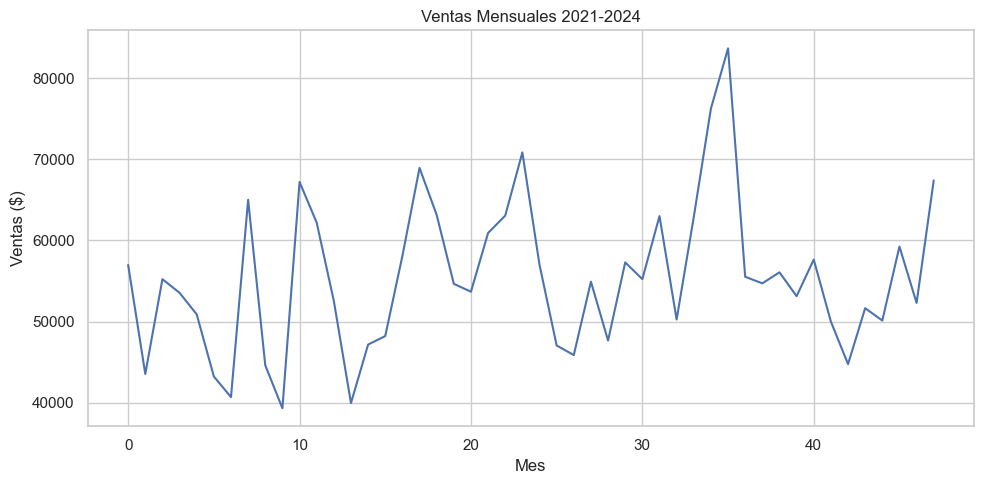

In [21]:
plt.plot(range(len(ventas_mes)), ventas_mes['Sales'])

plt.title('Ventas Mensuales 2021-2024')
plt.ylabel('Ventas ($)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

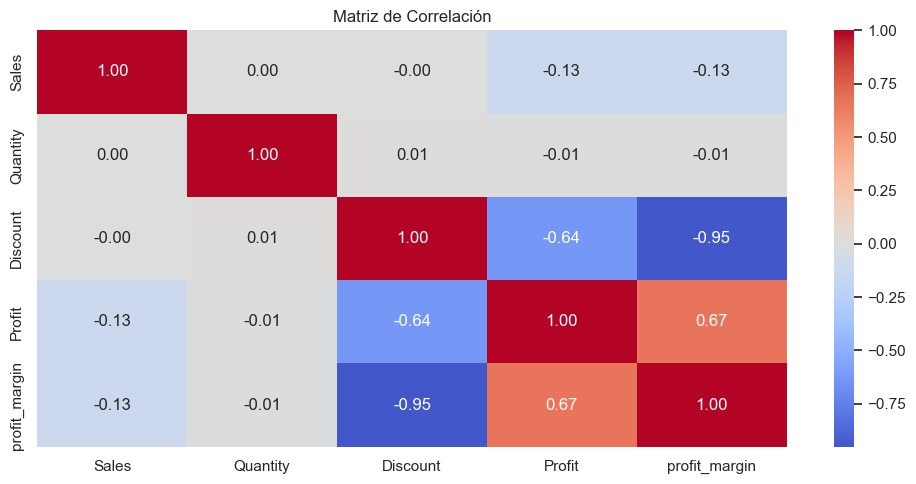

In [22]:
correlacion = df[['Sales', 'Quantity', 'Discount', 'Profit', 'profit_margin']].corr()

sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

In [24]:
from scipy import stats

west = df[df['Region'] == 'West']['Sales']
east = df[df['Region'] == 'East']['Sales']
central = df[df['Region'] == 'Central']['Sales']
south = df[df['Region'] == 'South']['Sales']

print(f"West promedio:    ${west.mean():,.0f}")
print(f"East promedio:    ${east.mean():,.0f}")
print(f"Central promedio: ${central.mean():,.0f}")
print(f"South promedio:   ${south.mean():,.0f}")

West promedio:    $262
East promedio:    $267
Central promedio: $264
South promedio:   $270


In [25]:
f_stat, p_value = stats.f_oneway(west, east, central, south)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("→ Diferencia SIGNIFICATIVA entre regiones")
else:
    print("→ No hay diferencia significativa entre regiones")

F-statistic: 0.3171
P-value:     0.8130
→ No hay diferencia significativa entre regiones


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("sklearn OK")

sklearn OK


In [28]:
ventas_modelo = df.groupby(['year', 'month'])['Sales'].sum().reset_index()

X = ventas_modelo[['year', 'month']]
y = ventas_modelo['Sales']

print(X.shape, y.shape)

(48, 2) (48,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} meses")
print(f"Prueba:        {X_test.shape[0]} meses")

Entrenamiento: 38 meses
Prueba:        10 meses


In [30]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado")
print(f"Coeficientes: year={modelo.coef_[0]:,.0f}  month={modelo.coef_[1]:,.0f}")
print(f"Intercepto:   {modelo.intercept_:,.0f}")

Modelo entrenado
Coeficientes: year=846  month=1,463
Intercepto:   -1,665,088


In [31]:
y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  $4,318
RMSE: $4,976
R²:   -0.786


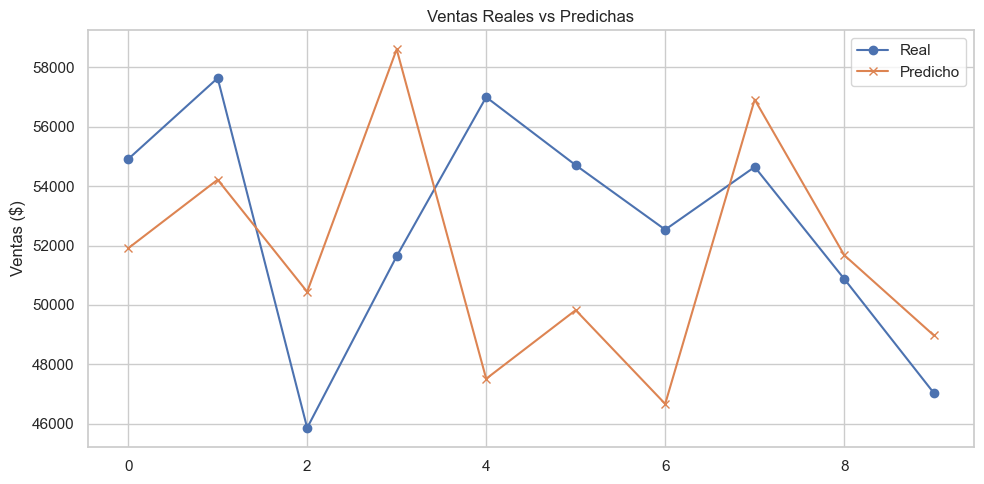

In [32]:
plt.plot(range(len(y_test)), y_test.values, label='Real', marker='o')
plt.plot(range(len(y_test)), y_pred, label='Predicho', marker='x')

plt.title('Ventas Reales vs Predichas')
plt.ylabel('Ventas ($)')
plt.legend()
plt.tight_layout()
plt.show()